<a href="https://colab.research.google.com/github/FernandaVil/unet-sst-inpainting/blob/main/02_entrenamiento_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import random
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from scipy.ndimage import gaussian_filter

def fijar_semillas(semilla=42):
    # anclar el generador nativo de python
    random.seed(semilla)

    # anclar las operaciones matemáticas (nuestras nubes fractales)
    np.random.seed(semilla)

    # anclar las operaciones de pytorch (cpu y gpu)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(semilla)
        torch.cuda.manual_seed_all(semilla)

    # forzar a la gpu a usar algoritmos convolucionales deterministas
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ejecutar la función
fijar_semillas(42)

In [ ]:

class ConfluenciaSSTLimpio(Dataset):
    def __init__(self, lista_archivos, ruta_datos, media_train, std_train, umbral_error=0.40):
        self.ruta_datos = ruta_datos
        self.archivos = lista_archivos
        self.umbral_error = umbral_error
        self.media = media_train
        self.std = std_train

    def __len__(self):
        return len(self.archivos)

    def _generar_nube_fractal(self, alto, ancho):
        for _ in range(10):
            mascara = np.ones((alto, ancho), dtype=np.float32)
            ruido = np.random.rand(alto, ancho)
            sigma_aleatorio = np.random.uniform(5, 20)
            ruido_suavizado = gaussian_filter(ruido, sigma=sigma_aleatorio)
            ruido_norm = (ruido_suavizado - ruido_suavizado.min()) / (ruido_suavizado.max() - ruido_suavizado.min())

            mascara[ruido_norm < 0.45] = 0.0
            if 1.0 - (mascara.sum() / (alto * ancho)) <= 0.60:
                return mascara

        mascara_segura = np.ones((alto, ancho), dtype=np.float32)
        mascara_segura[100:150, 100:150] = 0.0
        return mascara_segura

    def __getitem__(self, idx):
        datos = np.load(os.path.join(self.ruta_datos, self.archivos[idx]))
        sst = datos['sst'].astype(np.float32)
        error = datos['error'].astype(np.float32)
        alto, ancho = sst.shape

        # 1. normalización estadística
        sst_norm = (sst - self.media) / self.std

        # 2. generación de máscaras
        mascara_valida = (error <= self.umbral_error).astype(np.float32)
        mascara_nube = self._generar_nube_fractal(alto, ancho)

        # 3. oclusión del mapa normalizado
        sst_input = sst_norm * mascara_nube

        # 4. apilamiento de canales (input de 3 capas para la Res-UNet)
        tensor_input = np.stack([sst_input, mascara_nube, mascara_valida], axis=0)

        return {
            'input': torch.from_numpy(tensor_input),
            'target': torch.from_numpy(sst_norm).unsqueeze(0),
            'mascara_valida': torch.from_numpy(mascara_valida).unsqueeze(0)
        }

In [ ]:
import os
import numpy as np
from torch.utils.data import DataLoader

ruta_datos = '/content/drive/MyDrive/dataset_sst_confluencia'
# división cronológica (70% train, 15% val, 15% test)
archivos_totales = sorted([f for f in os.listdir(ruta_datos) if f.endswith('.npz')])
total = len(archivos_totales)
corte_train = int(total * 0.70)
corte_val = int(total * 0.85)

archivos_train = archivos_totales[:corte_train]
archivos_val = archivos_totales[corte_train:corte_val]
archivos_test = archivos_totales[corte_val:]

# cálculo iterativo de parámetros reales (solo sobre train)
print("calculando termodinámica base del conjunto de entrenamiento...")
temperaturas = []
for archivo in archivos_train:
    datos = np.load(os.path.join(ruta_datos, archivo))
    temperaturas.append(datos['sst'])

temperaturas_array = np.concatenate(temperaturas)
media_real = np.mean(temperaturas_array).item()
std_real = np.std(temperaturas_array).item()

print(f"media térmica: {media_real:.3f} °C | desviación estándar: {std_real:.3f}")

# instanciar clases con valores reales
dataset_train = ConfluenciaSSTLimpio(archivos_train, ruta_datos, media_real, std_real)
dataset_val = ConfluenciaSSTLimpio(archivos_val, ruta_datos, media_real, std_real)
dataset_test = ConfluenciaSSTLimpio(archivos_test, ruta_datos, media_real, std_real)

# empaquetado en memoria para la tarjeta gráfica
tamano_lote = 16
train_loader = DataLoader(dataset_train, batch_size=tamano_lote, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(dataset_val, batch_size=tamano_lote, shuffle=False, num_workers=2, drop_last=True)
test_loader = DataLoader(dataset_test, batch_size=tamano_lote, shuffle=False, num_workers=2, drop_last=True)

calculando termodinámica base del conjunto de entrenamiento...
media térmica: 14.028 °C | desviación estándar: 3.871


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BloqueConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNetSimplificada(nn.Module):
    def __init__(self, in_channels=3, capas_pooling=3):
        super().__init__()
        # calculamos el divisor mágico automático (2^3 = 8)
        self.divisor = 2 ** capas_pooling

        # ruta de bajada
        self.bajada1 = BloqueConv(in_channels, 32)
        self.bajada2 = BloqueConv(32, 64)
        self.bajada3 = BloqueConv(64, 128)

        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        # cuello de botella
        self.medio = BloqueConv(128, 256)

        # ruta de subida pura (sin interpolación distorsionada)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.subida3 = BloqueConv(256 + 128, 128)
        self.subida2 = BloqueConv(128 + 64, 64)
        self.subida1 = BloqueConv(64 + 32, 32)

        self.salida = nn.Conv2d(32, 1, kernel_size=1)

        # inicialización suave para arrancar estable
        nn.init.zeros_(self.salida.weight)
        if self.salida.bias is not None:
            nn.init.zeros_(self.salida.bias)

    def forward(self, x):
        # 1. el andamio: guardamos medidas y calculamos cuánto espejo necesitamos
        alto_original, ancho_original = x.shape[2], x.shape[3]

        pad_alto = (self.divisor - (alto_original % self.divisor)) % self.divisor
        pad_ancho = (self.divisor - (ancho_original % self.divisor)) % self.divisor

        # agregamos el andamio tipo espejo a la derecha y abajo
        x_pad = F.pad(x, (0, pad_ancho, 0, pad_alto), mode='reflect')

        # 2. ruta de bajada (matemática perfecta)
        c1 = self.bajada1(x_pad)
        p1 = self.pool(c1)

        c2 = self.bajada2(p1)
        p2 = self.pool(c2)

        c3 = self.bajada3(p2)
        p3 = self.pool(c3)

        # 3. cuello de botella
        m = self.medio(p3)

        # 4. ruta de subida (las matrices encajan al milímetro)
        u3 = self.upsample(m)
        u3 = torch.cat([u3, c3], dim=1)
        u3 = self.subida3(u3)

        u2 = self.upsample(u3)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.subida2(u2)

        u1 = self.upsample(u2)
        u1 = torch.cat([u1, c1], dim=1)
        u1 = self.subida1(u1)

        out_pad = self.salida(u1)

        # 5. corte de cirujano: desechamos el andamio y devolvemos 301x401 exactos
        out = out_pad[:, :, :alto_original, :ancho_original]

        return out

In [ ]:
import torch

def perdida_enmascarada(prediccion, objetivo, mascara_valida):
    # 1. calculamos el error al cuadrado en cada píxel individualmente
    error_cuadratico = (prediccion - objetivo) ** 2

    # 2. apagamos el error en las zonas donde el satélite original no era confiable
    error_filtrado = error_cuadratico * mascara_valida

    # 3. calculamos el promedio, dividiendo solo por la cantidad de píxeles que sí eran válidos
    # sumamos un número minúsculo (1e-8) para evitar que el código explote dividiendo por cero
    perdida_final = error_filtrado.sum() / (mascara_valida.sum() + 1e-8)

    return perdida_final

In [ ]:
import torch
import torch.optim as optim


# configuración de la revancha
epocas = 150
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"entrenando en: {dispositivo}")
modelo = UNetSimplificada(in_channels=3).to(dispositivo)

optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

# agregamos el planificador inteligente
planificador = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

mejor_perdida_val = float('inf') # reiniciamos el récord

entrenando en: cuda


In [ ]:
## BUCLE DE ENTRENAMIENTO

# 4. el bucle principal
for epoca in range(epocas):

    # --- fase de entrenamiento ---
    modelo.train() # le avisa a la red que estamos en modo aprendizaje
    perdida_train_total = 0.0

    for lote in train_loader:
        # movemos los tensores del lote actual a la tarjeta gráfica
        entradas = lote['input'].to(dispositivo)
        objetivos = lote['target'].to(dispositivo)
        mascaras = lote['mascara_valida'].to(dispositivo)

        # limpiar la memoria de los gradientes del paso anterior
        optimizador.zero_grad()

        # la red intenta predecir el mapa completo
        predicciones = modelo(entradas)

        # calculamos el error solo en los píxeles confiables
        perdida = perdida_enmascarada(predicciones, objetivos, mascaras)

        # magia matemática: propagar el error hacia atrás y ajustar los pesos
        perdida.backward()
        optimizador.step()

        perdida_train_total += perdida.item()

    promedio_train = perdida_train_total / len(train_loader)

    # --- fase de validación ---
    modelo.eval() # apaga ciertas capas para hacer una evaluación justa
    perdida_val_total = 0.0

    # apagamos el cálculo de gradientes para ahorrar mucha ram en colab
    with torch.no_grad():
        for lote in val_loader:
            entradas = lote['input'].to(dispositivo)
            objetivos = lote['target'].to(dispositivo)
            mascaras = lote['mascara_valida'].to(dispositivo)

            predicciones = modelo(entradas)
            perdida = perdida_enmascarada(predicciones, objetivos, mascaras)
            perdida_val_total += perdida.item()

    promedio_val = perdida_val_total / len(val_loader)

    # mostrar progreso en pantalla
    print(f"época {epoca+1}/{epocas} | pérdida train: {promedio_train:.4f} | pérdida val: {promedio_val:.4f}")

    # el planificador observa la pérdida de validación para decidir si achica el paso
    planificador.step(promedio_val)

    # guardar el modelo en el disco si superó su récord anterior
    if promedio_val < mejor_perdida_val:
        mejor_perdida_val = promedio_val
        torch.save(modelo.state_dict(), 'mejor_modelo_unet.pth')
        print("  -> ¡nuevo récord! guardando modelo...")
        # guardado directo y seguro a tu nube
        torch.save(modelo.state_dict(), '/content/drive/MyDrive/dataset_sst_confluencia/mejor_modelo_unet_revancha.pth')

época 1/150 | pérdida train: 0.4405 | pérdida val: 0.1611
  -> ¡nuevo récord! guardando modelo...
época 2/150 | pérdida train: 0.0884 | pérdida val: 0.0609
  -> ¡nuevo récord! guardando modelo...
época 3/150 | pérdida train: 0.0634 | pérdida val: 0.0265
  -> ¡nuevo récord! guardando modelo...
época 4/150 | pérdida train: 0.0507 | pérdida val: 0.0195
  -> ¡nuevo récord! guardando modelo...
época 5/150 | pérdida train: 0.0512 | pérdida val: 0.0170
  -> ¡nuevo récord! guardando modelo...
época 6/150 | pérdida train: 0.0507 | pérdida val: 0.0154
  -> ¡nuevo récord! guardando modelo...
época 7/150 | pérdida train: 0.0419 | pérdida val: 0.0197
época 8/150 | pérdida train: 0.0455 | pérdida val: 0.0122
  -> ¡nuevo récord! guardando modelo...
época 9/150 | pérdida train: 0.0560 | pérdida val: 0.0135
época 10/150 | pérdida train: 0.0474 | pérdida val: 0.0248
época 11/150 | pérdida train: 0.0445 | pérdida val: 0.0148
época 12/150 | pérdida train: 0.0467 | pérdida val: 0.0186
época 13/150 | pérdid

In [ ]:
# SI QUIERO GUARDAR EL MODELO EN DRIVE
import shutil
# copiamos el modelo desde la memoria volátil de colab hacia tu google drive
origen = 'mejor_modelo_unet.pth'
destino = '/content/drive/MyDrive/dataset_sst_confluencia/mejor_modelo_unet_150epocas.pth'
shutil.copy(origen, destino)
print("¡modelo guardado a salvo en google drive!")

In [ ]:
## SI QUIERO CARGAR EL MODELO QU EGUARDE:
# nos aseguramos de cargar el récord de la época 125
modelo.load_state_dict(torch.load('/content/drive/MyDrive/dataset_sst_confluencia/mejor_modelo_unet_revancha.pth'))
modelo.eval() # modo examen activado


UNetSimplificada(
  (bajada1): BloqueConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU(inplace=True)
    )
  )
  (bajada2): BloqueConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU(inplace=True)
    )
  )
  (bajada3): BloqueConv(


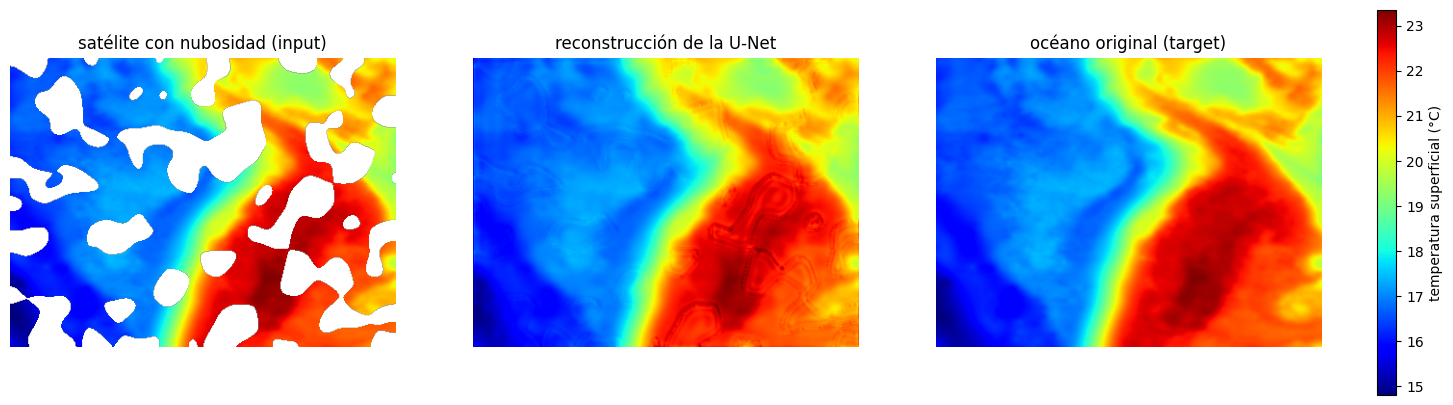

In [ ]:
import matplotlib.pyplot as plt

# 1. cargar los pesos del mejor modelo guardado
#modelo.load_state_dict(torch.load('mejor_modelo_unet.pth'))
modelo.eval() # apagar el modo de entrenamiento

# 2. extraer un lote al azar de los datos de validación
lote_prueba = next(iter(val_loader))
entradas_prueba = lote_prueba['input'].to(dispositivo)
objetivos_prueba = lote_prueba['target']

# 3. hacer la predicción sin calcular gradientes (ahorra memoria)
with torch.no_grad():
    predicciones = modelo(entradas_prueba).cpu() # lo devolvemos a la memoria normal

# 4. extraer la primera imagen del lote y desnormalizarla para ver grados celsius
idx = 1
sst_nublado = entradas_prueba[idx, 0].cpu().numpy() * std_real + media_real
sst_real = objetivos_prueba[idx, 0].numpy() * std_real + media_real
sst_predicho = predicciones[idx, 0].numpy() * std_real + media_real

# extraer la máscara de la nube (canal 1) para pintar el hueco de gris en el gráfico
mascara = entradas_prueba[idx, 1].cpu().numpy()
sst_nublado_visual = sst_nublado.copy()
sst_nublado_visual[mascara == 0] = np.nan

# 5. graficar los resultados lado a lado
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

# limites de temperatura para que los colores coincidan
vmin = np.nanmin(sst_real)
vmax = np.nanmax(sst_real)

# panel 1: lo que ve el satélite (con la nube)
im0 = ejes[0].imshow(sst_nublado_visual, cmap='jet', vmin=vmin, vmax=vmax)
ejes[0].set_title('satélite con nubosidad (input)')
ejes[0].axis('off')

# panel 2: la predicción de tu red neuronal
im1 = ejes[1].imshow(sst_predicho, cmap='jet', vmin=vmin, vmax=vmax)
ejes[1].set_title('reconstrucción de la U-Net')
ejes[1].axis('off')

# panel 3: la realidad termodinámica
im2 = ejes[2].imshow(sst_real, cmap='jet', vmin=vmin, vmax=vmax)
ejes[2].set_title('océano original (target)')
ejes[2].axis('off')

fig.colorbar(im2, ax=ejes.ravel().tolist(), label='temperatura superficial (°C)', fraction=0.02, pad=0.04)
plt.show()

Evaluacion final : U-Net vs. interpolacion

In [ ]:
import numpy as np
from scipy.interpolate import griddata

# 1. función clásica de las agencias
def rellenar_con_interpolacion(sst_entrada, mascara_nube):
    alto, ancho = sst_entrada.shape
    x, y = np.meshgrid(np.arange(ancho), np.arange(alto))
    es_valido = mascara_nube > 0.5
    puntos_validos = np.column_stack((y[es_valido], x[es_valido]))
    valores_validos = sst_entrada[es_valido]
    puntos_destino = np.column_stack((y.ravel(), x.ravel()))

    sst_interpolado = griddata(puntos_validos, valores_validos, puntos_destino, method='linear')
    if np.isnan(sst_interpolado).any():
        sst_interpolado = griddata(puntos_validos, valores_validos, puntos_destino, method='nearest')
    return sst_interpolado.reshape((alto, ancho))

# 2. preparamos un mapa del conjunto de testeo
lote_test = next(iter(test_loader))
entradas_test = lote_test['input'].to(dispositivo)
objetivos_test = lote_test['target']
mascaras_validas_test = lote_test['mascara_valida']

# predicción de tu red
with torch.no_grad():
    predicciones_unet = modelo(entradas_test).cpu()

# extraemos el primer mapa y pasamos a numpy
idx = 0
sst_input = entradas_test[idx, 0].cpu().numpy()
mascara_nube = entradas_test[idx, 1].cpu().numpy()
objetivo_real = objetivos_test[idx, 0].numpy()
mascara_valida = mascaras_validas_test[idx, 0].numpy()
pred_unet = predicciones_unet[idx, 0].numpy()

# predicción de scipy
pred_clasica = rellenar_con_interpolacion(sst_input, mascara_nube)

# 3. el paso clave: todo a grados celsius
objetivo_celsius = objetivo_real * std_real + media_real
unet_celsius = pred_unet * std_real + media_real
clasica_celsius = pred_clasica * std_real + media_real

# 4. evaluación estricta (solo donde hay mar válido y está tapado por nube)
zona_estricta = (mascara_valida == 1) & (mascara_nube == 0)

pixeles_reales = objetivo_celsius[zona_estricta]
pixeles_unet = unet_celsius[zona_estricta]
pixeles_clasicos = clasica_celsius[zona_estricta]

# 5. cálculo del error cuadrático medio (mse)
error_mse_unet = np.mean((pixeles_unet - pixeles_reales) ** 2)
error_mse_clasico = np.mean((pixeles_clasicos - pixeles_reales) ** 2)

print("--- evaluación final (solo bajo la nube, en grados celsius) ---")
print(f"mse u-net: {error_mse_unet:.4f} °c² (error lineal aprox: {np.sqrt(error_mse_unet):.2f} °c)")
print(f"mse interpolación clásica: {error_mse_clasico:.4f} °c² (error lineal aprox: {np.sqrt(error_mse_clasico):.2f} °c)")

--- evaluación final (solo bajo la nube, en grados celsius) ---
mse u-net: 0.1120 °c² (error lineal aprox: 0.33 °c)
mse interpolación clásica: 0.2326 °c² (error lineal aprox: 0.48 °c)


In [ ]:
import numpy as np
import torch

# nos aseguramos de que tu modelo cargado esté en modo evaluación
modelo.eval()

errores_unet = []
errores_clasicos = []

print("iniciando auditoría masiva sobre el conjunto de testeo...")
print("esto puede tardar un par de minutos dependiendo de la cantidad de mapas...")

# apagamos el cálculo de gradientes por completo
with torch.no_grad():
    for lote in test_loader:
        entradas = lote['input'].to(dispositivo)
        objetivos = lote['target']
        mascaras_validas = lote['mascara_valida']

        # 1. la red predice todos los mapas del lote de una sola vez
        predicciones_unet = modelo(entradas).cpu()

        # iteramos sobre cada mapa individual dentro de este lote
        for i in range(entradas.shape[0]):

            # extraemos las matrices de este mapa particular
            sst_input = entradas[i, 0].cpu().numpy()
            mascara_nube = entradas[i, 1].cpu().numpy()
            objetivo_real = objetivos[i, 0].numpy()
            mascara_val = mascaras_validas[i, 0].numpy()
            pred_unet = predicciones_unet[i, 0].numpy()

            # 2. interpolación clásica para el mismo mapa
            pred_clasica = rellenar_con_interpolacion(sst_input, mascara_nube)

            # 3. desnormalización a grados celsius puros
            objetivo_c = objetivo_real * std_real + media_real
            unet_c = pred_unet * std_real + media_real
            clasica_c = pred_clasica * std_real + media_real

            # 4. definimos el bisturí: solo píxeles válidos debajo de la nube
            zona = (mascara_val == 1) & (mascara_nube == 0)

            # seguridad: si por azar este mapa no tiene ningún píxel que cumpla esto, lo ignoramos
            if not np.any(zona):
                continue

            # 5. calculamos el mse para este mapa y lo guardamos en la lista
            mse_unet = np.mean((unet_c[zona] - objetivo_c[zona]) ** 2)
            mse_clasico = np.mean((clasica_c[zona] - objetivo_c[zona]) ** 2)

            errores_unet.append(mse_unet)
            errores_clasicos.append(mse_clasico)

# 6. cálculo de las métricas estadísticas finales
mse_final_unet = np.mean(errores_unet)
mse_final_clasico = np.mean(errores_clasicos)

print("\n--- resultados definitivos de la auditoría global ---")
print(f"mapas evaluados con éxito: {len(errores_unet)}")
print(f"rmse promedio u-net: {np.sqrt(mse_final_unet):.3f} °c")
print(f"rmse promedio interpolación: {np.sqrt(mse_final_clasico):.3f} °c")

iniciando auditoría masiva sobre el conjunto de testeo...
esto puede tardar un par de minutos dependiendo de la cantidad de mapas...

--- resultados definitivos de la auditoría global ---
mapas evaluados con éxito: 160
rmse promedio u-net: 0.346 °c
rmse promedio interpolación: 0.376 °c


buscando el escenario donde la u-net superó por mayor margen a scipy...


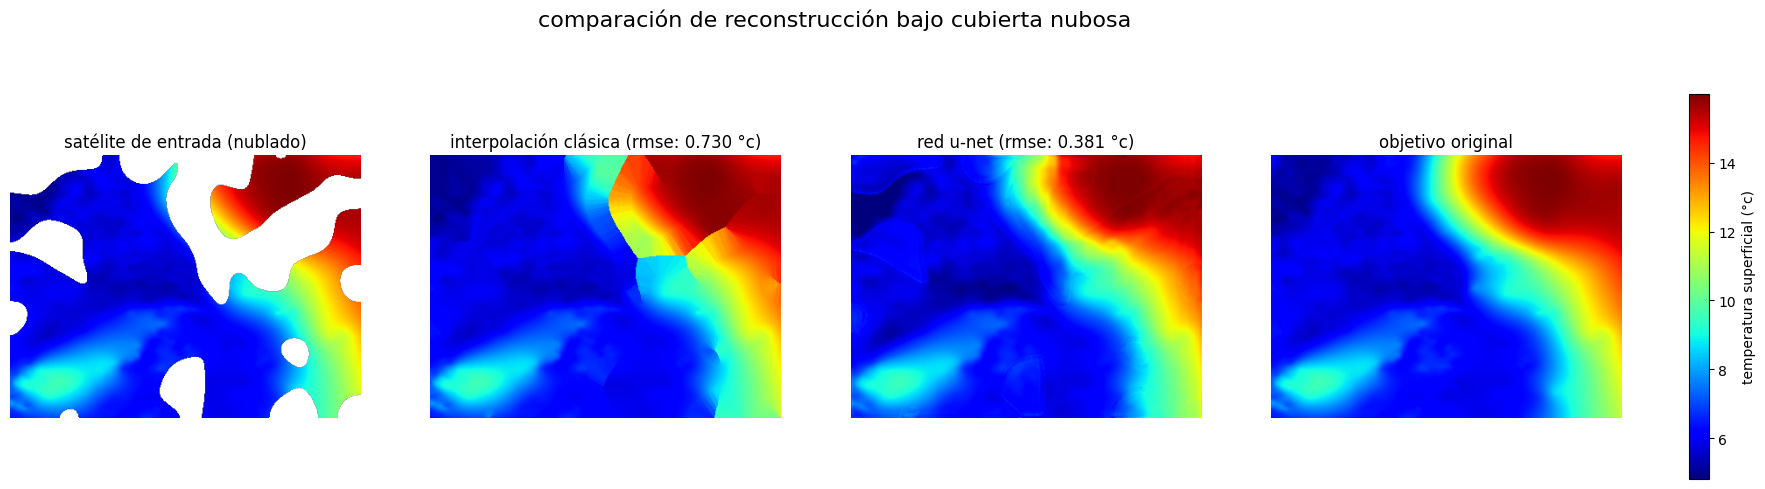

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

modelo.eval()
mayor_diferencia = -1
mejor_mapa = None

print("buscando el escenario donde la u-net superó por mayor margen a scipy...")

fijar_semillas(42)

with torch.no_grad():
    for lote in test_loader:
        entradas = lote['input'].to(dispositivo)
        objetivos = lote['target']
        mascaras_validas = lote['mascara_valida']

        predicciones_unet = modelo(entradas).cpu()

        for i in range(entradas.shape[0]):
            sst_input = entradas[i, 0].cpu().numpy()
            mascara_nube = entradas[i, 1].cpu().numpy()
            objetivo_real = objetivos[i, 0].numpy()
            mascara_val = mascaras_validas[i, 0].numpy()
            pred_unet = predicciones_unet[i, 0].numpy()

            # predicción clásica
            pred_clasica = rellenar_con_interpolacion(sst_input, mascara_nube)

            # desnormalizar todo a °C
            objetivo_c = objetivo_real * std_real + media_real
            unet_c = pred_unet * std_real + media_real
            clasica_c = pred_clasica * std_real + media_real

            # evaluar solo bajo la nube
            zona = (mascara_val == 1) & (mascara_nube == 0)
            if not np.any(zona):
                continue

            mse_unet = np.mean((unet_c[zona] - objetivo_c[zona])**2)
            mse_clasico = np.mean((clasica_c[zona] - objetivo_c[zona])**2)

            # buscamos la mayor victoria de la red
            diferencia = mse_clasico - mse_unet

            if diferencia > mayor_diferencia:
                mayor_diferencia = diferencia

                # preparamos el input visual (ponemos np.nan donde está la nube para que se vea un hueco)
                input_visual = np.copy(objetivo_c)
                input_visual[mascara_nube == 0] = np.nan

                mejor_mapa = {
                    'input': input_visual,
                    'unet': unet_c,
                    'clasica': clasica_c,
                    'objetivo': objetivo_c,
                    'rmse_unet': np.sqrt(mse_unet),
                    'rmse_clasica': np.sqrt(mse_clasico)
                }

# --- bloque de graficación de los 4 paneles ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# fijamos los mismos límites de color para que los 4 mapas sean comparables visualmente
vmin = np.nanmin(mejor_mapa['objetivo'])
vmax = np.nanmax(mejor_mapa['objetivo'])

# 1. input con nube
im0 = axes[0].imshow(mejor_mapa['input'], cmap='jet', vmin=vmin, vmax=vmax, origin='lower')
axes[0].set_title("satélite de entrada (nublado)")
axes[0].axis('off')

# 2. reconstrucción scipy
im1 = axes[1].imshow(mejor_mapa['clasica'], cmap='jet', vmin=vmin, vmax=vmax, origin='lower')
axes[1].set_title(f"interpolación clásica (rmse: {mejor_mapa['rmse_clasica']:.3f} °c)")
axes[1].axis('off')

# 3. reconstrucción u-net
im2 = axes[2].imshow(mejor_mapa['unet'], cmap='jet', vmin=vmin, vmax=vmax, origin='lower')
axes[2].set_title(f"red u-net (rmse: {mejor_mapa['rmse_unet']:.3f} °c)")
axes[2].axis('off')

# 4. objetivo real
im3 = axes[3].imshow(mejor_mapa['objetivo'], cmap='jet', vmin=vmin, vmax=vmax, origin='lower')
axes[3].set_title("objetivo original")
axes[3].axis('off')

# barra de color compartida
cbar = fig.colorbar(im3, ax=axes.ravel().tolist(), fraction=0.015, pad=0.04)
cbar.set_label('temperatura superficial (°c)')

plt.suptitle("comparación de reconstrucción bajo cubierta nubosa", fontsize=16, y=1.05)
plt.show()